# Phase C — Industrial Texture Training (DTD + MVTec AD)
### Conditional Texture Generator project — Phase C

**Where this picks up:** Phase A proved the diffusion math on MNIST. Phase B added class-conditional generation (Classifier-Free Guidance) on MNIST digits. This notebook keeps the **exact same `UNet` / `GaussianDiffusion` code** from Phase B and points it at real industrial-style textures instead of digits, in two stages:

1. **Stage 1 — DTD (Describable Textures Dataset).** Auto-downloads, 47 texture categories (banded, bumpy, woven, zigzagged, etc.). We train the conditional model here first because it needs no manual download and gives a fast, informative first look at real-texture generation quality.
2. **Stage 2 — MVTec AD (industrial anomaly detection).** Requires a manual download (free registration), but is the dataset that actually matches the project's stated production use case: generating synthetic **normal-class** textures to augment a **defect classifier**.

Both stages reuse the same model code and the same resume-from-Google-Drive checkpointing pattern as Phase A/B, so if you've run those notebooks this one will feel identical to operate.

**Before you run anything:** Runtime → Change runtime type → GPU (T4 is fine, but textures are RGB and higher-resolution than MNIST, so training will be slower per epoch than Phase A/B — expect roughly 3-6x the per-epoch time depending on batch size).


## 1. Mount Google Drive and set up project folders

Same pattern as Phase A/B: one resumable checkpoint file per model, overwritten every epoch and synced to Drive; everything disposable (raw dataset, mid-epoch safety saves, generated sample images) lives on Colab's local disk.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/diffusion_project/phase_c"

# ---- Stage 1: DTD ----
DTD_CKPT_DIR = os.path.join(PROJECT_ROOT, "dtd", "checkpoints")
DTD_DRIVE_CKPT_PATH = os.path.join(DTD_CKPT_DIR, "latest.pt")

# ---- Stage 2: MVTec AD ----
MVTEC_CKPT_DIR = os.path.join(PROJECT_ROOT, "mvtec", "checkpoints")
MVTEC_DRIVE_CKPT_PATH = os.path.join(MVTEC_CKPT_DIR, "latest.pt")

for d in [DTD_CKPT_DIR, MVTEC_CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- Everything disposable lives on local disk (fast, free, wiped on disconnect -- that's fine) ----
LOCAL_ROOT = "/content/local_work"
LOCAL_CHECKPOINT_DIR = os.path.join(LOCAL_ROOT, "checkpoints")
DATA_DIR = os.path.join(LOCAL_ROOT, "data")
SAMPLES_DIR = os.path.join(LOCAL_ROOT, "samples")

for d in [LOCAL_ROOT, LOCAL_CHECKPOINT_DIR, DATA_DIR, SAMPLES_DIR]:
    os.makedirs(d, exist_ok=True)

print("DTD checkpoint (Drive):", DTD_DRIVE_CKPT_PATH)
print("MVTec AD checkpoint (Drive):", MVTEC_DRIVE_CKPT_PATH)
print("Local scratch (disposable):", LOCAL_ROOT)


DTD checkpoint (Drive): /content/drive/MyDrive/diffusion_project/phase_c/dtd/checkpoints/latest.pt
MVTec AD checkpoint (Drive): /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoints/latest.pt
Local scratch (disposable): /content/local_work


## 2. Install dependencies and import libraries


In [3]:
!pip install -q torch-fidelity


In [4]:
import copy
import math
import time
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
import torchvision.utils as vutils

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cpu":
    print("WARNING: no GPU detected. Go to Runtime -> Change runtime type -> GPU.")


Using device: cuda


## 3. Model architecture (unchanged from Phase B)

`SinusoidalTimeEmbedding`, `ResBlock`, `SelfAttention`, `Downsample`, `Upsample`, and the class-conditional `UNet` are the **exact same classes as Phase B** -- class conditioning doesn't care whether the classes are digits or texture categories, and the CFG training/sampling logic in `GaussianDiffusion` doesn't either.

**The one thing that changes:** textures need more spatial detail than digits, so we go RGB (`in_channels=3`) and use one more downsampling level (`channel_mults=(1,2,4,8)` instead of `(1,2,4)`) at a larger image size (64x64 instead of 32x32). This pushes the self-attention bottleneck down to 8x8 as well as 16x16, which is exactly what `attention_resolutions=(16,8)` already expects -- no code changes needed, only different constructor arguments.


In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half_dim = self.dim // 2
        freq_scale = math.log(10000) / (half_dim - 1)
        freqs = torch.exp(torch.arange(half_dim, device=device) * -freq_scale)
        args = t[:, None].float() * freqs[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, cond_emb_dim: int, groups: int = 8):
        super().__init__()
        self.cond_mlp = nn.Sequential(nn.SiLU(), nn.Linear(cond_emb_dim, out_ch))
        self.block1 = nn.Sequential(
            nn.GroupNorm(groups, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(groups, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, cond_emb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        cond_bias = self.cond_mlp(cond_emb)
        h = h + cond_bias[:, :, None, None]
        h = self.block2(h)
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, channels: int, num_heads: int = 4, groups: int = 8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, channels)
        self.mha = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        x_norm = self.norm(x)
        x_flat = x_norm.view(b, c, h * w).transpose(1, 2)
        attn_out, _ = self.mha(x_flat, x_flat, x_flat)
        attn_out = attn_out.transpose(1, 2).view(b, c, h, w)
        return x + attn_out


class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.op = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)
    def forward(self, x):
        return self.op(x)


class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.op = nn.ConvTranspose2d(channels, channels, kernel_size=4, stride=2, padding=1)
    def forward(self, x):
        return self.op(x)


In [6]:
class UNet(nn.Module):
    """
    Class-conditional U-Net noise-prediction network -- identical design to
    Phase B, just instantiated with different defaults (RGB input, one
    extra downsampling level) for texture work. `num_classes` real classes
    plus ONE reserved "null" index (== num_classes) used for
    unconditional generation / CFG training dropout.
    """
    def __init__(
        self,
        in_channels: int = 3,
        base_channels: int = 64,
        channel_mults: tuple = (1, 2, 4, 8),
        time_emb_dim: int = 256,
        attention_resolutions: tuple = (16, 8),
        image_size: int = 64,
        num_classes: int = 47,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.null_class_idx = num_classes

        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.class_embed = nn.Embedding(num_classes + 1, base_channels)
        self.class_mlp = nn.Sequential(
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        self.down_blocks = nn.ModuleList()
        ch = base_channels
        cur_res = image_size
        self.skip_channels = [ch]

        for mult in channel_mults:
            out_ch = base_channels * mult
            self.down_blocks.append(ResBlock(ch, out_ch, time_emb_dim))
            ch = out_ch
            self.skip_channels.append(ch)
            if cur_res in attention_resolutions:
                self.down_blocks.append(SelfAttention(ch))
            self.down_blocks.append(ResBlock(ch, ch, time_emb_dim))
            self.skip_channels.append(ch)
            if mult != channel_mults[-1]:
                self.down_blocks.append(Downsample(ch))
                cur_res //= 2

        self.mid_block1 = ResBlock(ch, ch, time_emb_dim)
        self.mid_attn = SelfAttention(ch)
        self.mid_block2 = ResBlock(ch, ch, time_emb_dim)

        self.up_blocks = nn.ModuleList()
        skips_to_consume = list(self.skip_channels)

        for i, mult in enumerate(reversed(channel_mults)):
            out_ch = base_channels * mult
            is_last_level = (i == len(channel_mults) - 1)
            num_resblocks = 3 if is_last_level else 2
            for _ in range(num_resblocks):
                skip_ch = skips_to_consume.pop()
                self.up_blocks.append(ResBlock(ch + skip_ch, out_ch, time_emb_dim))
                ch = out_ch
            if cur_res in attention_resolutions:
                self.up_blocks.append(SelfAttention(ch))
            if not is_last_level:
                self.up_blocks.append(Upsample(ch))
                cur_res *= 2

        self.out_norm = nn.GroupNorm(8, ch)
        self.out_conv = nn.Conv2d(ch, in_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_embed(t)
        c_emb = self.class_mlp(self.class_embed(y))
        cond_emb = t_emb + c_emb

        h = self.in_conv(x)
        skips = [h]
        for layer in self.down_blocks:
            if isinstance(layer, ResBlock):
                h = layer(h, cond_emb)
                skips.append(h)
            elif isinstance(layer, Downsample):
                h = layer(h)
            else:
                h = layer(h)

        h = self.mid_block1(h, cond_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, cond_emb)

        for layer in self.up_blocks:
            if isinstance(layer, ResBlock):
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                h = layer(h, cond_emb)
            elif isinstance(layer, Upsample):
                h = layer(h)
            else:
                h = layer(h)

        h = self.out_norm(h)
        h = F.silu(h)
        return self.out_conv(h)


In [7]:
# Sanity check: forward pass with RGB textures + class labels runs and produces the right shape
_test_model = UNet(in_channels=3, base_channels=64, image_size=64, num_classes=47).to(device)
_dummy_x = torch.randn(4, 3, 64, 64).to(device)
_dummy_t = torch.randint(0, 1000, (4,)).to(device)
_dummy_y = torch.tensor([0, 3, 7, 47]).to(device)  # last one (47) = null/unconditional token
_out = _test_model(_dummy_x, _dummy_t, _dummy_y)
print("Output shape:", _out.shape, "(expected: torch.Size([4, 3, 64, 64]))")
print(f"Total parameters: {sum(p.numel() for p in _test_model.parameters()):,}")
del _test_model, _dummy_x, _dummy_t, _dummy_y, _out


Output shape: torch.Size([4, 3, 64, 64]) (expected: torch.Size([4, 3, 64, 64]))
Total parameters: 53,204,227


## 4. Diffusion math + Classifier-Free Guidance (unchanged from Phase B)


In [8]:
class GaussianDiffusion:
    def __init__(self, timesteps: int = 1000, beta_start: float = 1e-4, beta_end: float = 0.02, device: str = "cpu"):
        self.timesteps = timesteps
        self.device = device

        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]])

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)

    @staticmethod
    def _extract(values: torch.Tensor, t: torch.Tensor, shape: torch.Size) -> torch.Tensor:
        batch_size = t.shape[0]
        out = values.gather(0, t)
        return out.reshape(batch_size, *((1,) * (len(shape) - 1)))

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor = None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self._extract(self.sqrt_alphas_cumprod, t, x0.shape)
        sqrt_1m_ac = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape)
        x_t = sqrt_ac * x0 + sqrt_1m_ac * noise
        return x_t, noise

    def training_loss(self, model, x0: torch.Tensor, y: torch.Tensor, label_dropout: float = 0.15):
        batch_size = x0.shape[0]
        t = torch.randint(0, self.timesteps, (batch_size,), device=x0.device).long()
        noise = torch.randn_like(x0)
        x_t, noise = self.q_sample(x0, t, noise)

        drop_mask = torch.rand(batch_size, device=x0.device) < label_dropout
        y_input = y.clone()
        y_input[drop_mask] = model.null_class_idx

        predicted_noise = model(x_t, t, y_input)
        return F.mse_loss(predicted_noise, noise)

    @torch.no_grad()
    def p_sample_cfg(self, model, x_t: torch.Tensor, t: torch.Tensor, y: torch.Tensor, guidance_scale: float):
        batch_size = x_t.shape[0]
        null_y = torch.full((batch_size,), model.null_class_idx, device=x_t.device, dtype=torch.long)

        eps_cond = model(x_t, t, y)
        eps_uncond = model(x_t, t, null_y)
        predicted_noise = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        # Static thresholding: reconstruct the predicted clean image implied by this
        # noise prediction and clip it to the valid [-1, 1] range *before* using it to
        # form the posterior mean. Without this, a class whose embedding is weakly
        # trained (e.g. it had few training images, or CFG's guidance_scale amplifies
        # a small error into a large one) can produce a noise prediction that implies
        # an out-of-range x0. That error compounds across all 1000 steps and the whole
        # image collapses to solid black or white -- exactly the "some classes turn out
        # blank" failure mode. This is standard practice (Nichol & Dhariwal, 2021;
        # OpenAI's guided-diffusion) and is algebraically identical to the previous
        # formula whenever the unclipped x0 was already in range, so it changes nothing
        # for classes that were already sampling correctly.
        sqrt_ac_t = self._extract(self.sqrt_alphas_cumprod, t, x_t.shape)
        sqrt_1m_ac_t = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
        pred_x0 = (x_t - sqrt_1m_ac_t * predicted_noise) / sqrt_ac_t
        pred_x0 = pred_x0.clamp(-1.0, 1.0)

        alphas_cumprod_t = self._extract(self.alphas_cumprod, t, x_t.shape)
        alphas_cumprod_prev_t = self._extract(self.alphas_cumprod_prev, t, x_t.shape)
        alphas_t = self._extract(self.alphas, t, x_t.shape)
        betas_t = self._extract(self.betas, t, x_t.shape)

        posterior_mean = (
            torch.sqrt(alphas_cumprod_prev_t) * betas_t / (1.0 - alphas_cumprod_t) * pred_x0
            + torch.sqrt(alphas_t) * (1.0 - alphas_cumprod_prev_t) / (1.0 - alphas_cumprod_t) * x_t
        )

        if (t == 0).all():
            return posterior_mean
        else:
            posterior_var_t = self._extract(self.posterior_variance, t, x_t.shape)
            z = torch.randn_like(x_t)
            return posterior_mean + torch.sqrt(posterior_var_t) * z

    @torch.no_grad()
    def sample_cfg(self, model, image_shape: tuple, y: torch.Tensor, device: str,
                    guidance_scale: float = 3.0, return_trajectory: bool = False):
        model.eval()
        x_t = torch.randn(image_shape, device=device)
        trajectory = [x_t.cpu()] if return_trajectory else None

        for step in reversed(range(self.timesteps)):
            t_batch = torch.full((image_shape[0],), step, device=device, dtype=torch.long)
            x_t = self.p_sample_cfg(model, x_t, t_batch, y, guidance_scale)
            if return_trajectory and step % (self.timesteps // 10) == 0:
                trajectory.append(x_t.cpu())

        model.train()
        if return_trajectory:
            return x_t, trajectory
        return x_t


def denormalize(images: torch.Tensor) -> torch.Tensor:
    return (images.clamp(-1, 1) + 1) / 2


### EMA (exponential moving average) of model weights

Added to fix the guidance-scale ablation: raw training weights are noisy step to step, and classifier-free guidance *extrapolates* in the `(eps_cond - eps_uncond)` direction, so that noise gets amplified as `guidance_scale` increases -- this is exactly the "looks fine at scale=1, degrades into colored static by scale=5-7" pattern from the ablation grid above. Sampling from smoothed EMA weights instead of the raw training weights fixes this and is standard practice for diffusion models generally.

In [9]:
class EMA:
    """
    Exponential moving average of a model's weights, tracked as a separate
    copy that is nudged toward the raw training weights after every step:
        ema_weight = decay * ema_weight + (1 - decay) * raw_weight

    We always sample from `ema_model`, never the raw training `model` --
    see the markdown cell above for why this matters so much once
    classifier-free guidance is involved.

    `decay` sets the effective averaging window, roughly 1 / (1 - decay)
    steps. We use 0.995 (~200-step window) rather than the more typical
    0.999-0.9999 because this notebook's runs are short (on the order of a
    few thousand steps total) -- a slower EMA would barely have caught up
    to the model by the time training ends.
    """
    def __init__(self, model: nn.Module, decay: float = 0.995):
        self.decay = decay
        self.ema_model = copy.deepcopy(model).eval()
        for p in self.ema_model.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        for ema_p, p in zip(self.ema_model.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)
        for ema_b, b in zip(self.ema_model.buffers(), model.buffers()):
            ema_b.copy_(b)

    def state_dict(self):
        return self.ema_model.state_dict()

    def load_state_dict(self, state_dict):
        self.ema_model.load_state_dict(state_dict)


In [10]:
def train_model(model, diffusion, optimizer, dataloader, drive_ckpt_path, local_ckpt_dir,
                 epochs, start_epoch, label_dropout, save_every_n_steps, config,
                 ema=None, step_offset=0):
    """
    Generic resume-aware training loop, reused for both the DTD model and
    the MVTec AD model. Drive storage stays lean: one checkpoint file per
    model, overwritten every epoch; mid-epoch safety saves stay local only.

    If `ema` (an EMA instance) is passed, its shadow weights are updated
    every optimizer step and saved alongside the raw model weights, so
    sampling can always use the smoothed EMA weights instead of the noisy
    raw training weights.
    """
    def save_checkpoint(epoch, to_drive):
        payload = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "ema_state_dict": ema.state_dict() if ema is not None else None,
            "epoch": epoch,
            "config": config,
        }
        path = drive_ckpt_path if to_drive else os.path.join(local_ckpt_dir, "partial.pt")
        torch.save(payload, path)
        return path

    step = step_offset
    for epoch in range(start_epoch, epochs):
        running_loss = 0.0
        epoch_start = time.time()

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            loss = diffusion.training_loss(model, images, labels, label_dropout=label_dropout)
            loss.backward()
            optimizer.step()
            if ema is not None:
                ema.update(model)

            running_loss += loss.item()
            step += 1

            if step % 100 == 0:
                print(f"epoch {epoch} | step {step} | loss {loss.item():.4f}")
            if step % save_every_n_steps == 0:
                save_checkpoint(epoch, to_drive=False)

        avg_loss = running_loss / len(dataloader)
        print(f"=== Epoch {epoch} finished -- avg loss {avg_loss:.4f} -- {time.time()-epoch_start:.1f}s ===")

        ckpt_path = save_checkpoint(epoch, to_drive=True)
        print(f"Synced checkpoint to Drive: {ckpt_path}")

    print("Training complete (or reached EPOCHS target).")
    return step


# Stage 1 — DTD (Describable Textures Dataset)

## 5. Config and DTD dataset

DTD auto-downloads via `torchvision.datasets.DTD` and has **47 texture categories** (banded, bumpy, cracked, woven, zigzagged, etc.) -- a good general-purpose proxy for "industrial surface textures" with zero manual setup.


In [11]:
# ---------------- Config ----------------
IMAGE_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 2e-4
TIMESTEPS = 1000
LABEL_DROPOUT = 0.15
SAVE_EVERY_N_STEPS = 200

def get_dtd_dataloader():
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    dataset = datasets.DTD(root=DATA_DIR, split="train", partition=1, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
    return loader, dataset

dtd_dataloader, dtd_dataset = get_dtd_dataloader()
NUM_CLASSES_DTD = len(dtd_dataset.classes)
print(f"DTD classes ({NUM_CLASSES_DTD}):", dtd_dataset.classes)
print(f"Batches per epoch: {len(dtd_dataloader)}")


DTD classes (47): ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline', 'dotted', 'fibrous', 'flecked', 'freckled', 'frilly', 'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced', 'knitted', 'lacelike', 'lined', 'marbled', 'matted', 'meshed', 'paisley', 'perforated', 'pitted', 'pleated', 'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared', 'spiralled', 'sprinkled', 'stained', 'stratified', 'striped', 'studded', 'swirly', 'veined', 'waffled', 'woven', 'wrinkled', 'zigzagged']
Batches per epoch: 58


## 6. Training loop — resume-aware, single Drive checkpoint


In [12]:
dtd_model = UNet(in_channels=3, base_channels=64, image_size=IMAGE_SIZE, num_classes=NUM_CLASSES_DTD).to(device)
dtd_diffusion = GaussianDiffusion(timesteps=TIMESTEPS, device=device)
dtd_optimizer = torch.optim.AdamW(dtd_model.parameters(), lr=LEARNING_RATE)

n_params = sum(p.numel() for p in dtd_model.parameters())
print(f"Model parameters: {n_params:,}")

dtd_start_epoch = 0
dtd_ema_state = None  # populated below if the checkpoint has one
if os.path.exists(DTD_DRIVE_CKPT_PATH):
    print(f"Found checkpoint on Drive: {DTD_DRIVE_CKPT_PATH} -- resuming from it.")
    try:
        # weights_only=False is required here: newer PyTorch (>=2.6) defaults torch.load
        # to weights_only=True, which rejects the plain Python config dict and full
        # optimizer state we intentionally save alongside the model weights. This is
        # safe because we're loading a checkpoint this same notebook wrote to Drive.
        ckpt = torch.load(DTD_DRIVE_CKPT_PATH, map_location=device, weights_only=False)
    except Exception as e:
        raise RuntimeError(
            f"Failed to load checkpoint at {DTD_DRIVE_CKPT_PATH}: {e}\n"
            f"If this is a state_dict size-mismatch error, the checkpoint was likely saved "
            f"with different model settings (e.g. a different NUM_CLASSES_DTD or channel_mults) "
            f"than this run is using. Delete the checkpoint file or start a fresh run to fix it."
        ) from e
    dtd_model.load_state_dict(ckpt["model_state_dict"])
    dtd_optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    dtd_start_epoch = ckpt["epoch"] + 1
    dtd_ema_state = ckpt.get("ema_state_dict")
    print(f"Resuming training at epoch {dtd_start_epoch}")
    if dtd_start_epoch >= EPOCHS:
        print(f"NOTE: this checkpoint already finished epoch {ckpt['epoch']}, which is >= your "
              f"current EPOCHS={EPOCHS}. The training loop below will exit immediately with nothing "
              f"to do -- raise EPOCHS above {ckpt['epoch']} if you want to keep training.")
else:
    print("No checkpoint found on Drive -- starting fresh.")

# EMA copy used for all sampling (see the EMA class above). Built *after* the
# possible resume above so it starts from the resumed weights, not a fresh init.
dtd_ema = EMA(dtd_model, decay=0.995)
if dtd_ema_state is not None:
    dtd_ema.load_state_dict(dtd_ema_state)
    print("Loaded EMA weights from checkpoint.")
else:
    print("No EMA weights found (older checkpoint or fresh run) -- EMA initialized from current model weights.")


Model parameters: 53,204,227
Found checkpoint on Drive: /content/drive/MyDrive/diffusion_project/phase_c/dtd/checkpoints/latest.pt -- resuming from it.
Resuming training at epoch 30
NOTE: this checkpoint already finished epoch 29, which is >= your current EPOCHS=30. The training loop below will exit immediately with nothing to do -- raise EPOCHS above 29 if you want to keep training.
Loaded EMA weights from checkpoint.


In [13]:
dtd_config = {
    "in_channels": 3,
    "image_size": IMAGE_SIZE,
    "timesteps": TIMESTEPS,
    "num_classes": NUM_CLASSES_DTD,
    "class_names": dtd_dataset.classes,
}

train_model(
    model=dtd_model,
    diffusion=dtd_diffusion,
    optimizer=dtd_optimizer,
    dataloader=dtd_dataloader,
    drive_ckpt_path=DTD_DRIVE_CKPT_PATH,
    local_ckpt_dir=LOCAL_CHECKPOINT_DIR,
    epochs=EPOCHS,
    start_epoch=dtd_start_epoch,
    label_dropout=LABEL_DROPOUT,
    save_every_n_steps=SAVE_EVERY_N_STEPS,
    config=dtd_config,
    ema=dtd_ema,
)


Training complete (or reached EPOCHS target).


0

## 7. Generate texture samples per class


Generating classes: ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered']
Saved to /content/local_work/samples/dtd_class_grid_demo_s2.0.png


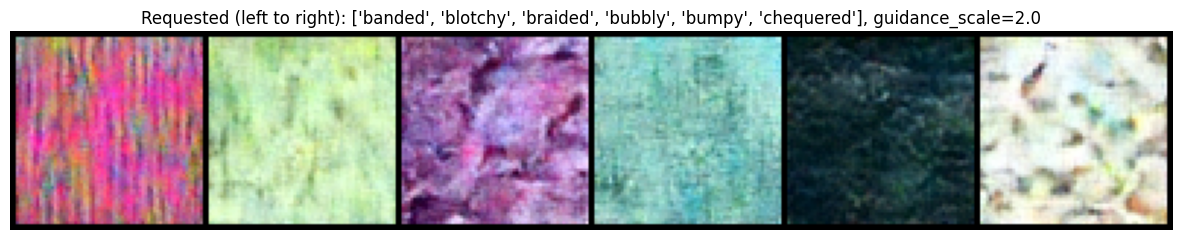

In [14]:
@torch.no_grad()
def generate_dtd_class_grid(class_indices, guidance_scale=2.0, tag="latest"):
    y = torch.tensor(class_indices, device=device, dtype=torch.long)
    image_shape = (len(class_indices), 3, IMAGE_SIZE, IMAGE_SIZE)
    images = dtd_diffusion.sample_cfg(dtd_ema.ema_model, image_shape, y, device, guidance_scale=guidance_scale)
    images = denormalize(images)
    grid = vutils.make_grid(images, nrow=len(class_indices))
    path = os.path.join(SAMPLES_DIR, f"dtd_class_grid_{tag}_s{guidance_scale}.png")
    vutils.save_image(grid, path)
    return grid, path

# Generate a handful of texture categories side by side
# NOTE: guidance_scale lowered from the original 3.0. With EMA now smoothing the
# sampling weights this should hold together noticeably better at higher scales,
# but a model trained this briefly still won't tolerate very large guidance well --
# see the ablation cell below. Push this back up once training runs longer.
DEMO_GUIDANCE_SCALE = 2.0
demo_class_indices = list(range(min(6, NUM_CLASSES_DTD)))
demo_class_names = [dtd_dataset.classes[i] for i in demo_class_indices]
print("Generating classes:", demo_class_names)
grid, path = generate_dtd_class_grid(demo_class_indices, guidance_scale=DEMO_GUIDANCE_SCALE, tag="demo")
print(f"Saved to {path}")

import matplotlib.pyplot as plt
img = plt.imread(path)
plt.figure(figsize=(15, 3))
plt.imshow(img)
plt.axis("off")
plt.title(f"Requested (left to right): {demo_class_names}, guidance_scale={DEMO_GUIDANCE_SCALE}")
plt.show()


## 8. Compare guidance scales (s = 1, 3, 5, 7)

Same ablation as Phase B, now on a texture category instead of a digit: low `s` should look more varied and less clearly "that texture"; high `s` should look more consistently on-category, at some cost to diversity if pushed too far.


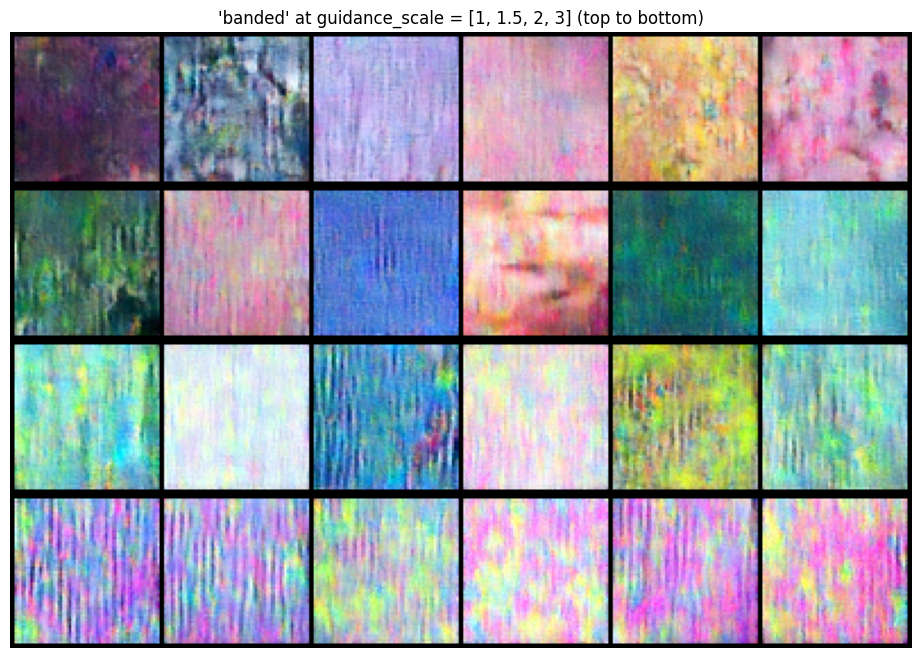

Saved to /content/local_work/samples/dtd_guidance_ablation_banded.png


In [15]:
# Lowered from [1, 3, 5, 7]: EMA should make higher scales hold together much
# better than before, but a model trained this briefly still won't tolerate very
# large guidance_scale well. Start here -- if these look clean, extend the list
# back out toward [1, 3, 5, 7] to see where it actually starts to degrade.
GUIDANCE_SCALES_TO_TEST = [1, 1.5, 2, 3]
TEST_CLASS_INDEX = 0
TEST_CLASS_NAME = dtd_dataset.classes[TEST_CLASS_INDEX]

rows = []
for s in GUIDANCE_SCALES_TO_TEST:
    y = torch.full((6,), TEST_CLASS_INDEX, device=device, dtype=torch.long)
    images = dtd_diffusion.sample_cfg(dtd_ema.ema_model, (6, 3, IMAGE_SIZE, IMAGE_SIZE), y, device, guidance_scale=s)
    images = denormalize(images)
    rows.append(vutils.make_grid(images, nrow=6))

ablation_grid = torch.cat(rows, dim=1)
ablation_path = os.path.join(SAMPLES_DIR, f"dtd_guidance_ablation_{TEST_CLASS_NAME}.png")
vutils.save_image(ablation_grid, ablation_path)

img = plt.imread(ablation_path)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title(f"'{TEST_CLASS_NAME}' at guidance_scale = {GUIDANCE_SCALES_TO_TEST} (top to bottom)")
plt.show()
print(f"Saved to {ablation_path}")


## 9. Downstream value experiment: synthetic augmentation for an under-represented class

DTD itself isn't a defect dataset, but we can still test the project's core claim -- *does synthetic data help when one class is rare?* -- right now, before MVTec AD is set up:

1. Artificially **undersample one DTD class** (simulating a rare/under-represented category, the same situation a rare defect type creates in a real inspection dataset).
2. Train a small CNN texture classifier on the resulting imbalanced training set.
3. **Generate synthetic samples of the rare class** with our trained diffusion model and add them back in at a few different levels.
4. Compare the rare class's accuracy with 0%, 25%, 50%, and 100% synthetic augmentation (relative to how many real examples of that class remain).

This mirrors the evaluation the project plan calls for in Phase C/9, using DTD as a stand-in while MVTec AD downloads in Stage 2 below.

**Note on sample sizes:** DTD's `train` split alone only has ~40 images per class, which is too few to undersample *and* hold out a meaningful validation set from. This experiment instead pools `train` + `val` + `test` (same partition) into one larger set (~120 images/class) purely for building the imbalanced train/val split -- the diffusion model itself is still trained only on `train`, as in sections 5-6.


In [16]:
RARE_CLASS_INDEX = 1
RARE_CLASS_NAME = dtd_dataset.classes[RARE_CLASS_INDEX]

# DTD's "train" split alone only has ~40 images per class (1880 / 47) -- taking 10% of
# that for the rare class leaves ~3 training images and ~1 validation image, which
# produces a degenerate, noisy 0.0-or-1.0 accuracy regardless of augmentation level.
# We build a separate, larger pool (train + val + test, same partition, same transform)
# *only* for this classification experiment -- the diffusion model itself still trains
# on "train" only, unchanged from sections 5/6.
_dtd_val_split = datasets.DTD(root=DATA_DIR, split="val", partition=1, download=True, transform=dtd_dataset.transform)
_dtd_test_split = datasets.DTD(root=DATA_DIR, split="test", partition=1, download=True, transform=dtd_dataset.transform)
classification_pool = torch.utils.data.ConcatDataset([dtd_dataset, _dtd_val_split, _dtd_test_split])
print(f"Classification pool size: {len(classification_pool)} images "
      f"(vs. {len(dtd_dataset)} in the diffusion-training-only 'train' split)")

MIN_RARE_TRAIN_KEPT = 15  # real rare-class images kept for training after undersampling
MIN_RARE_VAL = 8          # real rare-class images held out for validation
VAL_FRACTION_OTHER = 0.2

print(f"Simulating class imbalance on: '{RARE_CLASS_NAME}'")

all_labels = [classification_pool[i][1] for i in range(len(classification_pool))]
rare_indices = [i for i, lbl in enumerate(all_labels) if lbl == RARE_CLASS_INDEX]
other_indices = [i for i, lbl in enumerate(all_labels) if lbl != RARE_CLASS_INDEX]

import random
random.seed(0)
random.shuffle(rare_indices)
random.shuffle(other_indices)

n_val_rare = min(MIN_RARE_VAL, max(1, len(rare_indices) // 3))
n_keep_train_rare = min(MIN_RARE_TRAIN_KEPT, len(rare_indices) - n_val_rare)
if n_keep_train_rare < 1:
    raise ValueError(
        f"Only {len(rare_indices)} '{RARE_CLASS_NAME}' images are available across train+val+test -- "
        f"not enough to build a meaningful split. Pick a different RARE_CLASS_INDEX, or lower "
        f"MIN_RARE_VAL / MIN_RARE_TRAIN_KEPT above."
    )

val_rare_indices = rare_indices[:n_val_rare]
train_rare_indices = rare_indices[n_val_rare:n_val_rare + n_keep_train_rare]
held_out_rare_indices = rare_indices[n_val_rare + n_keep_train_rare:]  # simulates the "missing" majority

n_val_other = int(len(other_indices) * VAL_FRACTION_OTHER)
val_other_indices = other_indices[:n_val_other]
train_other_indices = other_indices[n_val_other:]

train_indices_base = train_rare_indices + train_other_indices
val_indices = val_rare_indices + val_other_indices

print(f"Real rare-class training images kept: {len(train_rare_indices)} (out of {len(rare_indices)} available)")
print(f"Rare-class validation images: {len(val_rare_indices)}")
print(f"Other-class training images: {len(train_other_indices)} | validation: {len(val_other_indices)}")


Classification pool size: 5640 images (vs. 1880 in the diffusion-training-only 'train' split)
Simulating class imbalance on: 'blotchy'
Real rare-class training images kept: 15 (out of 120 available)
Rare-class validation images: 8
Other-class training images: 4416 | validation: 1104


In [17]:
class TextureClassifier(nn.Module):
    """Small CNN classifier -- just enough capacity to distinguish DTD's 47 texture classes."""
    def __init__(self, num_classes, image_size=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (image_size // 8) * (image_size // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_classifier(train_dataset, val_dataset, num_classes, epochs=8, batch_size=32, lr=1e-3):
    clf = TextureClassifier(num_classes, image_size=IMAGE_SIZE).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    for epoch in range(epochs):
        clf.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(clf(images), labels)
            loss.backward()
            opt.step()

    clf.eval()
    correct_rare, total_rare = 0, 0
    correct_all, total_all = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = clf(images).argmax(dim=1)
            correct_all += (preds == labels).sum().item()
            total_all += labels.size(0)
            rare_mask = labels == RARE_CLASS_INDEX
            correct_rare += (preds[rare_mask] == labels[rare_mask]).sum().item()
            total_rare += rare_mask.sum().item()

    overall_acc = correct_all / max(total_all, 1)
    rare_acc = correct_rare / max(total_rare, 1)
    return overall_acc, rare_acc


In [18]:
class SyntheticTextureDataset(Dataset):
    """Wraps a folder of diffusion-generated images for one class as a labeled dataset."""
    def __init__(self, image_tensor, label, transform=None):
        self.images = image_tensor  # (N, C, H, W) in [0, 1]
        self.label = label
        self.transform = transform

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, self.label


@torch.no_grad()
def generate_synthetic_rare_class(n_images, guidance_scale=2.0, batch_size=32):
    out = []
    remaining = n_images
    while remaining > 0:
        this_batch = min(batch_size, remaining)
        y = torch.full((this_batch,), RARE_CLASS_INDEX, device=device, dtype=torch.long)
        images = dtd_diffusion.sample_cfg(dtd_ema.ema_model, (this_batch, 3, IMAGE_SIZE, IMAGE_SIZE), y, device,
                                           guidance_scale=guidance_scale)
        out.append(denormalize(images).cpu())
        remaining -= this_batch
    return torch.cat(out, dim=0)

# Normalize synthetic images the same way the real training data is normalized
synthetic_transform = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))


In [19]:
AUGMENTATION_LEVELS = [0, 25, 50, 100]  # percent of real kept-rare-class count, added as synthetic
results = []

base_train_dataset = Subset(classification_pool, train_indices_base)
val_dataset = Subset(classification_pool, val_indices)

for pct in AUGMENTATION_LEVELS:
    n_synthetic = int(len(train_rare_indices) * pct / 100)
    print(f"\n--- Augmentation level: {pct}% ({n_synthetic} synthetic '{RARE_CLASS_NAME}' images) ---")

    if n_synthetic > 0:
        synthetic_images = generate_synthetic_rare_class(n_synthetic, guidance_scale=2.0)
        synthetic_dataset = SyntheticTextureDataset(synthetic_images, RARE_CLASS_INDEX, transform=synthetic_transform)
        train_dataset = torch.utils.data.ConcatDataset([base_train_dataset, synthetic_dataset])
    else:
        train_dataset = base_train_dataset

    overall_acc, rare_acc = train_classifier(train_dataset, val_dataset, NUM_CLASSES_DTD, epochs=12)
    print(f"Overall val accuracy: {overall_acc:.3f} | '{RARE_CLASS_NAME}' val accuracy: {rare_acc:.3f}")
    results.append({"augmentation_pct": pct, "n_synthetic": n_synthetic,
                     "overall_acc": overall_acc, "rare_class_acc": rare_acc})

print("\n=== Summary: synthetic augmentation vs. rare-class accuracy ===")
for r in results:
    print(f"  {r['augmentation_pct']:>3}% synthetic (+{r['n_synthetic']:>3} images): "
          f"overall={r['overall_acc']:.3f}, '{RARE_CLASS_NAME}'={r['rare_class_acc']:.3f}")



--- Augmentation level: 0% (0 synthetic 'blotchy' images) ---
Overall val accuracy: 0.221 | 'blotchy' val accuracy: 0.000

--- Augmentation level: 25% (3 synthetic 'blotchy' images) ---
Overall val accuracy: 0.228 | 'blotchy' val accuracy: 0.000

--- Augmentation level: 50% (7 synthetic 'blotchy' images) ---
Overall val accuracy: 0.236 | 'blotchy' val accuracy: 0.000

--- Augmentation level: 100% (15 synthetic 'blotchy' images) ---
Overall val accuracy: 0.245 | 'blotchy' val accuracy: 0.000

=== Summary: synthetic augmentation vs. rare-class accuracy ===
    0% synthetic (+  0 images): overall=0.221, 'blotchy'=0.000
   25% synthetic (+  3 images): overall=0.228, 'blotchy'=0.000
   50% synthetic (+  7 images): overall=0.236, 'blotchy'=0.000
  100% synthetic (+ 15 images): overall=0.245, 'blotchy'=0.000


## 10. Checklist — is the DTD stage of Phase C ready?

1. **Generated textures look plausible per category** (section 7) -- recognizably "banded", "woven", etc., not just colored noise.
2. **Guidance scale ablation behaves as expected** (section 8) -- higher `s` should look more consistently on-category.
3. **Loss trends down and stabilizes** over training, similar to Phase A/B (texture data is noisier than MNIST, so expect a higher floor).
4. **The augmentation experiment (section 9) shows some signal** -- ideally the rare class's validation accuracy improves as synthetic augmentation increases from 0% to 100%. If it doesn't, try a higher guidance scale for the synthetic generation or more training epochs on the diffusion model itself before generating.

Once these hold, move on to **Stage 2 below**, which repeats the same pipeline on MVTec AD -- the dataset that actually has labeled defects, and therefore the dataset that matches the project's original defect-classifier use case.


---
# Stage 2 — MVTec AD (industrial anomaly detection)

## 11. Download MVTec AD directly in Colab

MVTec AD is only officially distributed through a free-registration form on
mvtec.com, so there's no single stable direct-download link for the whole
archive. The cell below instead pulls the six per-category `.tar.xz` archives
from a long-standing public mirror (the same one tools like Anomalib use
internally), validates each archive is complete before trusting it, caches
good copies on Drive so re-runs after a Colab disconnect don't re-download
from scratch, and extracts everything into the layout the rest of this
notebook expects:

```
MVTEC_ROOT/
  carpet/
    train/
      good/            <- only "good" (normal) images live in train, by MVTec's design
        000.png ...
    test/
      good/
      color/           <- defect-type subfolders
      cut/
      ...
  grid/
    ...
  leather/
    ...
  tile/
    ...
  wood/
    ...
  metal_nut/
    ...
```

No manual download/upload step needed -- just run the next cell. It's
idempotent: re-running it will skip any category whose archive is already
present and valid, either locally or in the Drive cache.

**Why this matters for the project:** MVTec AD's `train/good` folders contain
**only defect-free images** -- that's intentional, since MVTec AD is built for
anomaly detection, not supervised classification. We use those defect-free
images to train our conditional diffusion model (one class per texture
category), then use the model to generate extra synthetic *normal* images.
The labeled defective images only exist in `test/`, so the downstream
classifier experiment in section 15 builds its own train/val split out of
`test/` rather than assuming labeled defects exist in `train/`.

*(License note: MVTec AD is CC BY-NC-SA -- non-commercial, share-alike, with
attribution -- regardless of which mirror it's pulled from.)*


In [20]:
import subprocess
import tarfile

MVTEC_ROOT = "/content/mvtec_ad"
MVTEC_RAW_DIR = "/content/mvtec_ad_raw"
DRIVE_CACHE_DIR = "/content/drive/MyDrive/diffusion_project/mvtec_cache"
os.makedirs(MVTEC_ROOT, exist_ok=True)
os.makedirs(MVTEC_RAW_DIR, exist_ok=True)
os.makedirs(DRIVE_CACHE_DIR, exist_ok=True)

MVTEC_URLS = {
    "carpet":    "https://www.mydrive.ch/shares/150455/eac7fbce84d93a5094e13f391170eca4/download/420937484-1629959013/carpet.tar.xz",
    "grid":      "https://www.mydrive.ch/shares/150456/bb0b2e3dc804ccb8b4485e01f8e4493b/download/420937487-1629959044/grid.tar.xz",
    "leather":   "https://www.mydrive.ch/shares/150458/923030ce14e10a7d147e95d0f8885f6b/download/420937607-1629959262/leather.tar.xz",
    "metal_nut": "https://www.mydrive.ch/shares/150459/c68856a21dca589b0f8ff6d4ee0f18f4/download/420937637-1629959294/metal_nut.tar.xz",
    "tile":      "https://www.mydrive.ch/shares/150462/5479f0fdc97bc6fa16eab0cb0cf0109f/download/420938133-1629960456/tile.tar.xz",
    "wood":      "https://www.mydrive.ch/shares/150465/d5b4115b720cdb54d217e75636e6e374/download/420938383-1629960649/wood.tar.xz",
}

def archive_is_valid(path):
    """Fully reads the archive's member list, which forces decompression of the
    whole file -- a truncated/corrupted .tar.xz will raise here rather than only
    failing later during extraction."""
    try:
        with tarfile.open(path) as tar:
            tar.getmembers()
        return True
    except Exception:
        return False

MAX_RETRIES = 2

for name, url in MVTEC_URLS.items():
    dest = os.path.join(MVTEC_RAW_DIR, f"{name}.tar.xz")
    drive_dest = os.path.join(DRIVE_CACHE_DIR, f"{name}.tar.xz")

    # Reuse a local copy only if it's actually a complete, valid archive
    if os.path.exists(dest) and archive_is_valid(dest):
        print(f"{name}: valid local copy already present, skipping download.")
        continue
    if os.path.exists(dest):
        print(f"{name}: local copy exists but is corrupt/incomplete -- removing and re-downloading.")
        os.remove(dest)

    # Try the Drive cache next, but validate it too -- don't trust a cached corrupt file forever
    if os.path.exists(drive_dest) and archive_is_valid(drive_dest):
        print(f"{name}: found valid cached copy on Drive -- copying locally.")
        subprocess.run(["cp", drive_dest, dest], check=True)
        continue
    elif os.path.exists(drive_dest):
        print(f"{name}: Drive cache is corrupt -- discarding it too.")
        os.remove(drive_dest)

    for attempt in range(1, MAX_RETRIES + 1):
        print(f"Downloading {name} (attempt {attempt}/{MAX_RETRIES}) ...")
        subprocess.run(["wget", "-q", "--show-progress", "-O", dest, url])
        size_mb = os.path.getsize(dest) / 1e6 if os.path.exists(dest) else 0
        if size_mb < 1:
            print(f"  WARNING: {name}.tar.xz is only {size_mb:.2f} MB -- likely a gated/HTML response.")
            if os.path.exists(dest):
                os.remove(dest)
            continue
        if archive_is_valid(dest):
            print(f"  OK -- {size_mb:.1f} MB, verified complete.")
            subprocess.run(["cp", dest, drive_dest], check=True)  # cache the GOOD copy only
            break
        else:
            print(f"  Downloaded {size_mb:.1f} MB but the archive is incomplete/corrupt -- retrying.")
            os.remove(dest)
    else:
        print(f"  FAILED to get a valid archive for '{name}' after {MAX_RETRIES} attempts.")

print("\nExtracting...")
for name in MVTEC_URLS:
    fpath = os.path.join(MVTEC_RAW_DIR, f"{name}.tar.xz")
    if not os.path.exists(fpath):
        continue
    try:
        with tarfile.open(fpath) as tar:
            tar.extractall(MVTEC_ROOT, filter="data")  # filter="data" avoids the Py3.14 deprecation warning
        print(f"  extracted {name}")
    except tarfile.ReadError as e:
        print(f"  WARNING: {name}.tar.xz failed to extract ({e}) -- delete {fpath} and re-run to retry.")

print("\nContents of MVTEC_ROOT:", os.listdir(MVTEC_ROOT))

MVTEC_CATEGORIES = [c for c in MVTEC_URLS
                    if os.path.isdir(os.path.join(MVTEC_ROOT, c, "train", "good"))]
missing = [c for c in MVTEC_URLS if c not in MVTEC_CATEGORIES]
if missing:
    print(f"NOTE: these categories are still missing a valid train/good folder: {missing}")
print("Using categories:", MVTEC_CATEGORIES)


carpet: found valid cached copy on Drive -- copying locally.
grid: found valid cached copy on Drive -- copying locally.
leather: found valid cached copy on Drive -- copying locally.
metal_nut: found valid cached copy on Drive -- copying locally.
tile: found valid cached copy on Drive -- copying locally.
  OK -- 498.1 MB, verified complete.

Extracting...
  extracted carpet
  extracted grid
  extracted leather
  extracted metal_nut
  extracted tile
  extracted wood

Contents of MVTEC_ROOT: ['tile', 'carpet', 'wood', 'metal_nut', 'leather', 'grid']
Using categories: ['carpet', 'grid', 'leather', 'metal_nut', 'tile', 'wood']


In [21]:
class MVTecNormalDataset(Dataset):
    """
    Walks `train/good` for each category and returns (image, category_index)
    pairs. This is the "normal-class" data the conditional diffusion model
    trains on -- one class per texture category, exactly like DTD's classes
    above but restricted to defect-free images.
    """
    def __init__(self, root, categories, transform=None):
        self.transform = transform
        self.categories = categories
        self.samples = []  # list of (path, category_index)
        for idx, category in enumerate(categories):
            good_dir = os.path.join(root, category, "train", "good")
            if not os.path.isdir(good_dir):
                continue
            for fname in sorted(os.listdir(good_dir)):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    self.samples.append((os.path.join(good_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        from PIL import Image
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

    def per_category_counts(self):
        counts = {c: 0 for c in self.categories}
        for _, idx in self.samples:
            counts[self.categories[idx]] += 1
        return counts


def get_mvtec_dataloader():
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    dataset = MVTecNormalDataset(MVTEC_ROOT, MVTEC_CATEGORIES, transform=transform)

    counts = dataset.per_category_counts()
    print("Per-category image counts:", counts)
    empty_categories = [c for c, n in counts.items() if n == 0]
    if empty_categories:
        raise ValueError(
            f"These categories have ZERO images under {MVTEC_ROOT}: {empty_categories}. "
            f"This is the #1 cause of a category generating solid black/blank images later -- "
            f"its class embedding never sees a single real training example. Check that "
            f"{MVTEC_ROOT}/<category>/train/good/ actually contains files for each of "
            f"{MVTEC_CATEGORIES}, fix the path or MVTEC_CATEGORIES, and re-run this cell."
        )

    # Weighted sampling so every category gets roughly equal expected exposure per
    # epoch, even if some categories have noticeably more/fewer real images than
    # others. A category that's rarely sampled gets a weakly-trained class embedding,
    # which is the second most common cause of a specific class collapsing to a
    # degenerate (often solid black) output during generation.
    sample_weights = [1.0 / counts[dataset.categories[label]] for _, label in dataset.samples]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(dataset), replacement=True)

    loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, drop_last=True)
    return loader, dataset

mvtec_dataloader, mvtec_dataset = get_mvtec_dataloader()
NUM_CLASSES_MVTEC = len(MVTEC_CATEGORIES)
print(f"MVTec AD 'good' training images found: {len(mvtec_dataset)}")
print(f"Categories ({NUM_CLASSES_MVTEC}): {MVTEC_CATEGORIES}")


Per-category image counts: {'carpet': 280, 'grid': 264, 'leather': 245, 'metal_nut': 220, 'tile': 230, 'wood': 247}
MVTec AD 'good' training images found: 1486
Categories (6): ['carpet', 'grid', 'leather', 'metal_nut', 'tile', 'wood']


## 12. Train the MVTec AD conditional model

Reuses the exact same `UNet`, `GaussianDiffusion`, and `train_model` from above -- only the dataloader, class count, and checkpoint path are different.

**If a category still generates solid black/blank images after training:** this most commonly means either (a) that category had zero or very few real training images (check the per-category counts printed in section 11 -- the weighted sampler above only helps if there's *some* real data to sample from), or (b) it just needs more epochs -- some class embeddings converge slower than others, especially with only ~200-300 images per category. `p_sample_cfg` above already clips the predicted clean image to `[-1, 1]` at every step specifically to stop a slow-converging class from spiraling into a degenerate output, but that's a safety net, not a substitute for that class actually being trained.


In [22]:
mvtec_model = UNet(in_channels=3, base_channels=64, image_size=IMAGE_SIZE, num_classes=NUM_CLASSES_MVTEC).to(device)
mvtec_diffusion = GaussianDiffusion(timesteps=TIMESTEPS, device=device)
mvtec_optimizer = torch.optim.AdamW(mvtec_model.parameters(), lr=LEARNING_RATE)

MVTEC_EPOCHS = 40  # MVTec categories are small (~200-400 images each) so a few more epochs helps

mvtec_start_epoch = 0
mvtec_ema_state = None  # populated below if the checkpoint has one
if os.path.exists(MVTEC_DRIVE_CKPT_PATH):
    print(f"Found checkpoint on Drive: {MVTEC_DRIVE_CKPT_PATH} -- resuming from it.")
    try:
        # weights_only=False is required here: newer PyTorch (>=2.6) defaults torch.load
        # to weights_only=True, which rejects the plain Python config dict and full
        # optimizer state we intentionally save alongside the model weights. This is
        # safe because we're loading a checkpoint this same notebook wrote to Drive.
        ckpt = torch.load(MVTEC_DRIVE_CKPT_PATH, map_location=device, weights_only=False)
    except Exception as e:
        raise RuntimeError(
            f"Failed to load checkpoint at {MVTEC_DRIVE_CKPT_PATH}: {e}\n"
            f"If this is a state_dict size-mismatch error, the checkpoint was likely saved "
            f"with different model settings (e.g. a different NUM_CLASSES_MVTEC or MVTEC_CATEGORIES "
            f"list) than this run is using. Delete the checkpoint file or start a fresh run to fix it."
        ) from e
    mvtec_model.load_state_dict(ckpt["model_state_dict"])
    mvtec_optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    mvtec_start_epoch = ckpt["epoch"] + 1
    mvtec_ema_state = ckpt.get("ema_state_dict")
    print(f"Resuming training at epoch {mvtec_start_epoch}")
    if mvtec_start_epoch >= MVTEC_EPOCHS:
        print(f"NOTE: this checkpoint already finished epoch {ckpt['epoch']}, which is >= your "
              f"current MVTEC_EPOCHS={MVTEC_EPOCHS}. The training loop below will exit immediately "
              f"with nothing to do -- raise MVTEC_EPOCHS above {ckpt['epoch']} if you want to keep training.")
else:
    print("No checkpoint found on Drive -- starting fresh.")

# EMA copy used for all sampling (see the EMA class earlier in the notebook).
# Built *after* the possible resume above so it starts from the resumed
# weights rather than a fresh init.
mvtec_ema = EMA(mvtec_model, decay=0.995)
if mvtec_ema_state is not None:
    mvtec_ema.load_state_dict(mvtec_ema_state)
    print("Loaded EMA weights from checkpoint.")
else:
    print("No EMA weights found (older checkpoint or fresh run) -- EMA initialized from current model weights.")


No checkpoint found on Drive -- starting fresh.
No EMA weights found (older checkpoint or fresh run) -- EMA initialized from current model weights.


In [23]:
mvtec_config = {
    "in_channels": 3,
    "image_size": IMAGE_SIZE,
    "timesteps": TIMESTEPS,
    "num_classes": NUM_CLASSES_MVTEC,
    "class_names": MVTEC_CATEGORIES,
}

train_model(
    model=mvtec_model,
    diffusion=mvtec_diffusion,
    optimizer=mvtec_optimizer,
    dataloader=mvtec_dataloader,
    drive_ckpt_path=MVTEC_DRIVE_CKPT_PATH,
    local_ckpt_dir=LOCAL_CHECKPOINT_DIR,
    epochs=MVTEC_EPOCHS,
    start_epoch=mvtec_start_epoch,
    label_dropout=LABEL_DROPOUT,
    save_every_n_steps=SAVE_EVERY_N_STEPS,
    config=mvtec_config,
    ema=mvtec_ema,
)


=== Epoch 0 finished -- avg loss 0.2471 -- 49.2s ===
Synced checkpoint to Drive: /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoints/latest.pt
=== Epoch 1 finished -- avg loss 0.0672 -- 50.7s ===
Synced checkpoint to Drive: /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoints/latest.pt
epoch 2 | step 100 | loss 0.0398
=== Epoch 2 finished -- avg loss 0.0559 -- 48.6s ===
Synced checkpoint to Drive: /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoints/latest.pt
=== Epoch 3 finished -- avg loss 0.0495 -- 50.1s ===
Synced checkpoint to Drive: /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoints/latest.pt
epoch 4 | step 200 | loss 0.0440
=== Epoch 4 finished -- avg loss 0.0438 -- 58.2s ===
Synced checkpoint to Drive: /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoints/latest.pt
=== Epoch 5 finished -- avg loss 0.0393 -- 48.6s ===
Synced checkpoint to Drive: /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoi

1840

## 13. Generate synthetic normal-class samples per category


Categories: ['carpet', 'grid', 'leather', 'metal_nut', 'tile', 'wood']
Saved to /content/local_work/samples/mvtec_class_grid_demo_s2.0.png


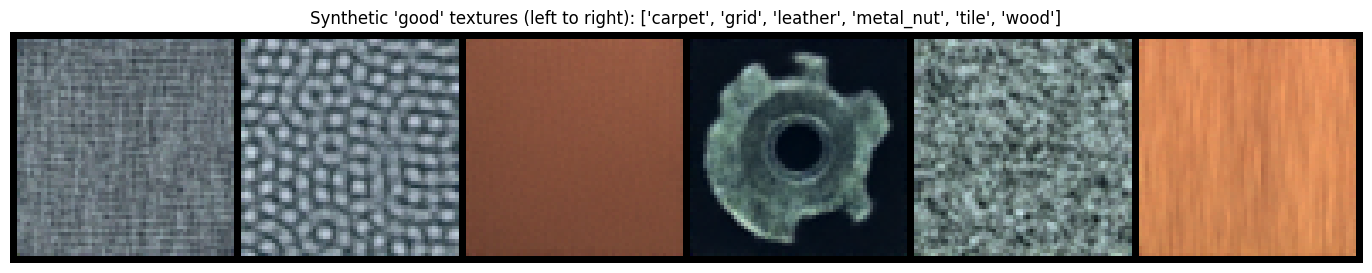

In [24]:
@torch.no_grad()
def generate_mvtec_class_grid(class_indices, guidance_scale=2.0, tag="latest"):
    y = torch.tensor(class_indices, device=device, dtype=torch.long)
    image_shape = (len(class_indices), 3, IMAGE_SIZE, IMAGE_SIZE)
    images = mvtec_diffusion.sample_cfg(mvtec_ema.ema_model, image_shape, y, device, guidance_scale=guidance_scale)
    images = denormalize(images)
    grid = vutils.make_grid(images, nrow=len(class_indices))
    path = os.path.join(SAMPLES_DIR, f"mvtec_class_grid_{tag}_s{guidance_scale}.png")
    vutils.save_image(grid, path)
    return grid, path

demo_indices = list(range(NUM_CLASSES_MVTEC))
grid, path = generate_mvtec_class_grid(demo_indices, guidance_scale=2.0, tag="demo")
print("Categories:", MVTEC_CATEGORIES)
print(f"Saved to {path}")

img = plt.imread(path)
plt.figure(figsize=(3 * NUM_CLASSES_MVTEC, 3))
plt.imshow(img)
plt.axis("off")
plt.title(f"Synthetic 'good' textures (left to right): {MVTEC_CATEGORIES}")
plt.show()


## 14. Build a labeled good/defective split from `test/`

As noted in section 11, MVTec's `train/` is defect-free by design, so labeled defective examples only exist in `test/`. This cell builds a simple binary (good vs. defective) dataset per category from `test/`, then splits it into a small train/val split for the classifier experiment below. Sample counts here are inherently small (MVTec AD test sets are typically 40-160 images per category) -- treat the resulting numbers as directional, not statistically rigorous.


In [25]:
CLASSIFIER_CATEGORY = MVTEC_CATEGORIES[0] if MVTEC_CATEGORIES else "wood"  # pick one category for the demo
print(f"Building good/defective split for category: '{CLASSIFIER_CATEGORY}'")

class MVTecTestSplitDataset(Dataset):
    """0 = good, 1 = defective, built from a category's test/ folder."""
    def __init__(self, root, category, transform=None):
        self.transform = transform
        self.samples = []
        test_dir = os.path.join(root, category, "test")
        for subfolder in sorted(os.listdir(test_dir)) if os.path.isdir(test_dir) else []:
            label = 0 if subfolder == "good" else 1
            folder_path = os.path.join(test_dir, subfolder)
            if not os.path.isdir(folder_path):
                continue
            for fname in sorted(os.listdir(folder_path)):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    self.samples.append((os.path.join(folder_path, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        from PIL import Image
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

classifier_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_test_dataset = MVTecTestSplitDataset(MVTEC_ROOT, CLASSIFIER_CATEGORY, transform=classifier_transform)
all_test_labels = [lbl for _, lbl in full_test_dataset.samples]
good_idx = [i for i, lbl in enumerate(all_test_labels) if lbl == 0]
defect_idx = [i for i, lbl in enumerate(all_test_labels) if lbl == 1]

random.seed(0)
random.shuffle(good_idx)
random.shuffle(defect_idx)

def split(indices, val_fraction=0.3):
    n_val = max(1, int(len(indices) * val_fraction))
    return indices[n_val:], indices[:n_val]

good_train_idx, good_val_idx = split(good_idx)
defect_train_idx, defect_val_idx = split(defect_idx)

classifier_train_indices = good_train_idx + defect_train_idx
classifier_val_indices = good_val_idx + defect_val_idx

print(f"Real 'good' train/val: {len(good_train_idx)}/{len(good_val_idx)}")
print(f"Real defective train/val: {len(defect_train_idx)}/{len(defect_val_idx)}")


Building good/defective split for category: 'carpet'
Real 'good' train/val: 20/8
Real defective train/val: 63/26


## 15. Defect classifier: 0% / 25% / 50% / 100% synthetic normal-class augmentation

This is the project's core downstream-value claim: does adding **synthetic normal-class images** (generated by our diffusion model) improve a good-vs-defective classifier, given how few real labeled images MVTec AD's test split actually provides? We keep the real defective images fixed and only add synthetic *normal* images to the "good" side of training, at increasing levels relative to the real "good" training count.


In [26]:
class BinaryClassifier(nn.Module):
    """Small CNN for good (0) vs. defective (1) classification."""
    def __init__(self, image_size=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (image_size // 8) * (image_size // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_binary_classifier(train_dataset, val_dataset, epochs=10, batch_size=16, lr=1e-3):
    clf = BinaryClassifier(image_size=IMAGE_SIZE).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    for epoch in range(epochs):
        clf.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(clf(images), labels)
            loss.backward()
            opt.step()

    clf.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = clf(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / max(total, 1)


@torch.no_grad()
def generate_synthetic_normal_for_category(category_name, n_images, guidance_scale=2.0, batch_size=16):
    class_idx = MVTEC_CATEGORIES.index(category_name)
    out = []
    remaining = n_images
    while remaining > 0:
        this_batch = min(batch_size, remaining)
        y = torch.full((this_batch,), class_idx, device=device, dtype=torch.long)
        images = mvtec_diffusion.sample_cfg(mvtec_ema.ema_model, (this_batch, 3, IMAGE_SIZE, IMAGE_SIZE), y, device,
                                             guidance_scale=guidance_scale)
        out.append(denormalize(images).cpu())
        remaining -= this_batch
    return torch.cat(out, dim=0)


In [27]:
defect_results = []
base_classifier_train = Subset(full_test_dataset, classifier_train_indices)
classifier_val = Subset(full_test_dataset, classifier_val_indices)

for pct in [0, 25, 50, 100]:
    n_synthetic = int(len(good_train_idx) * pct / 100)
    print(f"\n--- Augmentation level: {pct}% ({n_synthetic} synthetic 'good' {CLASSIFIER_CATEGORY} images) ---")

    if n_synthetic > 0:
        synthetic_images = generate_synthetic_normal_for_category(CLASSIFIER_CATEGORY, n_synthetic, guidance_scale=2.0)
        synthetic_dataset = SyntheticTextureDataset(synthetic_images, 0, transform=synthetic_transform)  # label 0 = good
        train_dataset = torch.utils.data.ConcatDataset([base_classifier_train, synthetic_dataset])
    else:
        train_dataset = base_classifier_train

    val_acc = train_binary_classifier(train_dataset, classifier_val)
    print(f"Validation accuracy: {val_acc:.3f}")
    defect_results.append({"augmentation_pct": pct, "n_synthetic": n_synthetic, "val_acc": val_acc})

print("\n=== Summary: synthetic 'good' augmentation vs. good/defective classifier accuracy ===")
for r in defect_results:
    print(f"  {r['augmentation_pct']:>3}% synthetic (+{r['n_synthetic']:>3} images): accuracy={r['val_acc']:.3f}")



--- Augmentation level: 0% (0 synthetic 'good' carpet images) ---
Validation accuracy: 0.765

--- Augmentation level: 25% (5 synthetic 'good' carpet images) ---
Validation accuracy: 0.765

--- Augmentation level: 50% (10 synthetic 'good' carpet images) ---
Validation accuracy: 0.765

--- Augmentation level: 100% (20 synthetic 'good' carpet images) ---
Validation accuracy: 0.765

=== Summary: synthetic 'good' augmentation vs. good/defective classifier accuracy ===
    0% synthetic (+  0 images): accuracy=0.765
   25% synthetic (+  5 images): accuracy=0.765
   50% synthetic (+ 10 images): accuracy=0.765
  100% synthetic (+ 20 images): accuracy=0.765


## 16. Checklist — is Phase C complete and ready for Phase D?

1. **DTD stage (Stage 1) checklist above passes** -- plausible per-category textures, sane guidance ablation, positive augmentation signal.
2. **MVTec AD model trains and generates plausible normal-class textures per category** (section 13) -- should visibly resemble the category's defect-free texture (e.g. `wood` grain, `carpet` weave).
3. **The good/defective classifier experiment (section 15) runs end-to-end** and produces a 4-row accuracy table. Because MVTec's test sets are small, don't over-read a single run -- consider averaging over a few random seeds if you want a more trustworthy trend line.
4. **Per-class / per-category FID** (optional, same `torch_fidelity` pattern as Phase A/B) can be added for either dataset if you want a numeric fidelity score alongside the visual checks.

Once these hold, you're ready for **Phase D: DDIM accelerated sampling + a Gradio demo (select a texture class → generate → animate denoising) + the final technical README** -- just say the word and it'll be built on top of whichever of the two Phase C models (DTD or MVTec AD) you want to ship.
